In [ ]:
# ── Cell 1 : Dependencies ──────────────────────────────────────────
!pip install pennylane pennylane-lightning-gpu umap-learn scipy -q

In [ ]:
# ── Cell 2 : Imports & Global Configuration ──────────────────────────
import os
import sys
import random
import warnings
import hashlib
import time
import tracemalloc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from scipy.stats import wilcoxon, pearsonr, spearmanr
from joblib import dump, load

import pennylane as qml

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    warnings.warn('umap-learn not found — UMAP visualization will be skipped.', ImportWarning)

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Dataset path — override via environment variable ────────────────────
DATASET_PATH = os.environ.get(
    'DATASET_PATH',
    '/dataset_encoded_normalized1.csv'
)

# ── Quantum circuit hyperparameters ──────────────────────────────────
N_LAYERS     = 3           # number of parametric layers per base learner
ENTANGLEMENT = 'circular'  # topology used for all base learners
DE_MAXITER   = 20
DE_POPSZ     = 10
N_SPLITS_CV  = 5

# ── Cache ───────────────────────────────────────────────────────
CACHE_DIR = 'cache_angular_quantum_ensemble_pub'
os.makedirs(CACHE_DIR, exist_ok=True)

FIGDIR = os.path.join(CACHE_DIR, 'figures')
os.makedirs(FIGDIR, exist_ok=True)

print(f'PennyLane version : {qml.version()}')
print(f'Python            : {sys.version.split()[0]}')
print(f'NumPy             : {np.__version__}')
print(f'Dataset path      : {DATASET_PATH}')
print(f'Cache directory   : {os.path.abspath(CACHE_DIR)}')

PennyLane version : 0.44.1
Python            : 3.13.11
NumPy             : 2.4.1
Dataset path      : /home/host1-vm4/Downloads/dataset_encoded_normalized1.csv
Cache directory   : /home/host1-vm4/cache_angular_quantum_ensemble_pub


In [ ]:
# ── Cell 3 : Data Loading & Strict 3-Way Split (70 / 15 / 15) ────────────
#
# FIX (data leakage): strict 3-way split.
#   X_train (70%) — DE weight optimization + base learner training
#   X_val   (15%) — DE objective evaluation ONLY
#   X_test  (15%) — final holdout, touched ONCE at the very end
#
# FIX: quantum features scaled to [-π, π] for meaningful RX angular encoding.
# MinMaxScaler fitted on X_train only.

assert os.path.exists(DATASET_PATH), (
    f'Dataset not found at "{DATASET_PATH}". '
    f'Set the DATASET_PATH environment variable or update the default path.'
)

df = pd.read_csv(DATASET_PATH)
assert 'LN_IC50' in df.columns, "Target column 'LN_IC50' not found in dataset."

X_raw = df.drop(columns=['LN_IC50']).values.astype(np.float64)
Y     = df['LN_IC50'].values.astype(np.float64)

N_FEATURES = X_raw.shape[1]
n_qubits   = N_FEATURES   # 12 qubits for 12 features — no PCA

HASH = hashlib.md5(X_raw.data.tobytes()).hexdigest()[:8]

print(f'Dataset  : {X_raw.shape[0]} samples × {N_FEATURES} features')
print(f'Target   : LN_IC50  mean={Y.mean():.3f}  std={Y.std():.3f}  '
      f'min={Y.min():.3f}  max={Y.max():.3f}')
print(f'Hash     : {HASH}')

# 70 / 15 / 15 split
X_tr_raw, X_temp, Y_train, Y_temp = train_test_split(
    X_raw, Y, test_size=0.30, random_state=SEED, shuffle=True
)
X_val_raw, X_test_raw, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=SEED
)

# FIX: scale to [-π, π] for angular encoding
scaler  = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train = scaler.fit_transform(X_tr_raw)   # fit on train only
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print(f'\nSplit — Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print('Features scaled to [-π, π] (MinMaxScaler fitted on X_train only).')
print('X_test will be touched ONCE at the final evaluation cell.')

Dataset  : 13106 samples × 12 features
Target   : LN_IC50  mean=0.538  std=0.134  min=0.000  max=1.000
Hash     : 8f057170

Split — Train: 9174  Val: 1966  Test: 1966
Features scaled to [-π, π] (MinMaxScaler fitted on X_train only).
X_test will be touched ONCE at the final evaluation cell.


In [ ]:
# ── Cell 4 : Quantum Device Initialization ─────────────────────────────

try:
    dev_gpu = qml.device('lightning.gpu', wires=n_qubits)
    DEVICE_LABEL = 'lightning.gpu'
    print(f'GPU device ready : lightning.gpu | {n_qubits} qubits')
except Exception as e:
    warnings.warn(
        f'GPU device unavailable ({e}). Falling back to lightning.qubit (CPU).',
        RuntimeWarning
    )
    dev_gpu = qml.device('lightning.qubit', wires=n_qubits)
    DEVICE_LABEL = 'lightning.qubit (CPU fallback)'

dev_cpu = qml.device('default.qubit', wires=n_qubits)

print(f'Active device    : {DEVICE_LABEL}')
print(f'Benchmark device : default.qubit (CPU reference)')

GPU device ready : lightning.gpu | 12 qubits
Active device    : lightning.gpu
Benchmark device : default.qubit (CPU reference)


In [ ]:
# ── Cell 5 : Quantum Circuit Factory ────────────────────────────────────
#
# FIX: QNode built ONCE per topology via build_circuit().
# FIX: Parallel (loky) removed — loky forks new processes that cannot
#      share a CUDA context, causing silent GPU failures. Sequential
#      iteration on the GPU is both correct and fast for 12 qubits.

def build_circuit(device, topology='circular'):
    """Build a PennyLane QNode on `device` with the given entanglement topology."""
    @qml.qnode(device, interface='autograd')
    def circuit(weights, x=None):
        for i in range(n_qubits):
            qml.RX(x[i], wires=i)
        n_layers = weights.shape[0]
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(weights[layer, i], wires=i)
            if topology == 'linear':
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
            elif topology == 'circular':
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
            elif topology == 'full':
                for i in range(n_qubits):
                    for j in range(i + 1, n_qubits):
                        qml.CNOT(wires=[i, j])
            else:
                raise ValueError(f"Unknown topology '{topology}'.")
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return circuit


def quantum_feature_map(X_data, weights, circuit_fn, verbose=False):
    """Sequential quantum feature map — GPU-safe (no loky parallelism)."""
    n = len(X_data)
    features = []
    for idx, xi in enumerate(X_data):
        features.append(np.array(circuit_fn(weights, x=xi)))
        if verbose and (idx + 1) % max(1, n // 10) == 0:
            print(f'  Feature map: {idx + 1}/{n} samples')
    return np.array(features)


# Build default circuit (GPU, circular) — shared across base learners
circuit_default = build_circuit(dev_gpu, topology=ENTANGLEMENT)
print(f'Circuit ready | topology={ENTANGLEMENT} | n_qubits={n_qubits} | N_LAYERS={N_LAYERS}')

Circuit ready | topology=circular | n_qubits=12 | N_LAYERS=3


In [ ]:
# ── Cell 5b : Base Learner Definitions & Hyperparameter Grids ─────────────────
#
# FIX: BASE_LEARNERS, tuning grids, cache paths, LEARNER_COLORS, and
# tune_base_learner() were missing — causing NameError in Cell 6 and beyond.

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from joblib import dump, load

# ── Base learner registry (name → unfitted estimator) ─────────────────────────
BASE_LEARNERS = [
    ('dt',  DecisionTreeRegressor(random_state=SEED)),
    ('rf',  RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ('mlp', Pipeline([('scaler', StandardScaler()),
                      ('mlp', MLPRegressor(max_iter=500, random_state=SEED))])),
]

# ── Hyperparameter search spaces ───────────────────────────────────────────────
DT_PARAMS = {
    'max_depth':        [None, 3, 5, 7, 10],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', None],
}
RF_PARAMS = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None, 5, 10],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2'],
}
MLP_PARAMS = {
    'mlp__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'mlp__alpha':              [1e-4, 1e-3, 1e-2],
    'mlp__learning_rate_init': [1e-3, 5e-4, 1e-2],
    'mlp__activation':         ['relu', 'tanh'],
}

# ── Per-learner joblib cache paths ─────────────────────────────────────────────
DT_CACHE  = os.path.join(CACHE_DIR, 'tuned_dt.joblib')
RF_CACHE  = os.path.join(CACHE_DIR, 'tuned_rf.joblib')
MLP_CACHE = os.path.join(CACHE_DIR, 'tuned_mlp.joblib')

# ── Colours used in convergence & importance plots ────────────────────────────
LEARNER_COLORS = {'dt': '#2563EB', 'rf': '#16A34A', 'mlp': '#DC2626'}

# ── Generic tuning helper (RandomizedSearchCV, cv=5) ──────────────────────────
def tune_base_learner(estimator, param_dist, X_tr, Y_tr, label, cache_path, n_iter=20):
    if os.path.exists(cache_path):
        print(f"  [{label}] Tuned model loaded from cache: {cache_path}")
        return load(cache_path)
    print(f"  [{label}] Tuning with RandomizedSearchCV ({n_iter} iter, {N_SPLITS_CV}-fold)...")
    search = RandomizedSearchCV(
        estimator, param_dist,
        n_iter=n_iter,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV,
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_tr, Y_tr)
    best = search.best_estimator_
    dump(best, cache_path)
    print(f"  [{label}] Best params : {search.best_params_}")
    print(f"  [{label}] Best CV MSE : {-search.best_score_:.6f}")
    return best

print(f"BASE_LEARNERS defined : {[n for n,_ in BASE_LEARNERS]}")
print("Hyperparameter grids, cache paths, colours, and tune_base_learner() ready.")


BASE_LEARNERS defined : ['dt', 'rf', 'mlp']
Hyperparameter grids, cache paths, colours, and tune_base_learner() ready.


In [ ]:
from sklearn.tree import DecisionTreeRegressor
def _build_proxy_model():
    return DecisionTreeRegressor(max_depth=5, random_state=SEED)

# ── Cell 6 : COBYLA — Weight Optimization ─────────────────────────────────────
#
# Replaces Differential Evolution with COBYLA.
# Optimization on 200 proxy samples — feature map final on full dataset.
#
# Justification: PQC weights learn a general feature transformation, not
# sample-specific mappings. 200 stratified samples capture the global structure.
# Final feature map and all model evaluation use the FULL dataset.
# Consistent with proxy optimization in variational quantum algorithms
# (Cerezo et al. 2021 [15], McClean et al. 2018 [20] — already cited).

from scipy.optimize import minimize

# ── Proxy subset: 200 samples, fixed seed ─────────────────────────────────────
np.random.seed(SEED)
PROXY_IDX = np.random.choice(len(X_train), 200, replace=False)
X_proxy   = X_train[PROXY_IDX]
Y_proxy   = Y_train[PROXY_IDX]

call_counter = {'n': 0}


def make_objective(circuit_fn, n_lay, history):
    def objective(weights_flat):
        call_counter['n'] += 1
        weights = weights_flat.reshape((n_lay, n_qubits))

        X_q  = quantum_feature_map(X_proxy, weights, circuit_fn)
        split    = int(0.8 * len(Y_proxy))
        X_sub    = X_q[:split];    X_val_p = X_q[split:]
        Y_sub    = Y_proxy[:split]; Y_val_p = Y_proxy[split:]

        _model = _build_proxy_model()
        _model.fit(X_sub, Y_sub)
        mse = mean_squared_error(Y_val_p, _model.predict(X_val_p))

        history.append((call_counter['n'], mse))
        if call_counter['n'] % 50 == 0 or call_counter['n'] <= 3:
            print(f'  [COBYLA call {call_counter["n"]:4d}]  val MSE = {mse:.6f}')
        return mse
    return objective


def run_cobyla(circuit_fn, n_lay, weights_file=None, history=None):
    if weights_file and os.path.exists(weights_file):
        w = np.load(weights_file).reshape((n_lay, n_qubits))
        print(f'  Weights loaded from cache: {weights_file}')
        return w

    call_counter['n'] = 0
    if history is not None:
        history.clear()
    else:
        history = []

    obj = make_objective(circuit_fn, n_lay, history)

    N_RESTARTS     = 3
    COBYLA_MAXITER = 300
    best_result    = None

    print(f'  COBYLA: {n_lay} layers x {n_qubits} qubits = {n_lay*n_qubits} params')
    print(f'  Proxy : 200 samples | {N_RESTARTS} restarts x {COBYLA_MAXITER} calls max')
    t0 = time.time()

    for restart in range(N_RESTARTS):
        np.random.seed(SEED + restart)
        x0 = np.random.uniform(-2*np.pi, 2*np.pi, n_lay * n_qubits)
        result = minimize(
            obj, x0, method='COBYLA',
            options={'maxiter': COBYLA_MAXITER, 'rhobeg': 0.5, 'catol': 1e-4}
        )
        print(f'  Restart {restart+1}/{N_RESTARTS} — val MSE = {result.fun:.6f}')
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    elapsed = time.time() - t0
    print(f'  Done in {elapsed/60:.1f} min | best val MSE = {best_result.fun:.6f}')

    w = best_result.x.reshape((n_lay, n_qubits))
    if weights_file:
        np.save(weights_file, w)
    return w


# ── Optimization loop — one per base learner ──────────────────────────────────
print('Optimizing circuit weights with COBYLA (200 proxy samples, per learner)...')
best_weights = {}
for clf_name, _ in BASE_LEARNERS:
    cobyla_history    = []
    call_counter['n'] = 0
    w_file    = os.path.join(CACHE_DIR, f'cobyla_weights_{clf_name}.npy')
    hist_file = os.path.join(CACHE_DIR, f'de_history_{clf_name}.npy')
    print(f'\nOptimizing weights for [{clf_name}]...')
    best_weights[clf_name] = run_cobyla(
        circuit_default, N_LAYERS,
        weights_file=w_file,
        history=cobyla_history
    )
    if cobyla_history:
        np.save(hist_file, np.array(cobyla_history))
        print(f'  History saved → {hist_file}')

print('\nAll weights optimized.')
print(f'Learners done: {list(best_weights.keys())}')


Optimizing circuit weights with COBYLA (200 proxy samples, per learner)...

Optimizing weights for [dt]...
  COBYLA: 3 layers x 12 qubits = 36 params
  Proxy : 200 samples | 3 restarts x 300 calls max
  [COBYLA call    1]  val MSE = 0.016224
  [COBYLA call    2]  val MSE = 0.016990
  [COBYLA call    3]  val MSE = 0.014834
  [COBYLA call   50]  val MSE = 0.014606
  [COBYLA call  100]  val MSE = 0.009383
  [COBYLA call  150]  val MSE = 0.009383
  [COBYLA call  200]  val MSE = 0.009383
  Restart 1/3 — val MSE = 0.009383
  [COBYLA call  250]  val MSE = 0.015756
  [COBYLA call  300]  val MSE = 0.008337
  [COBYLA call  350]  val MSE = 0.007949
  [COBYLA call  400]  val MSE = 0.007949
  Restart 2/3 — val MSE = 0.007949
  [COBYLA call  450]  val MSE = 0.015757
  [COBYLA call  500]  val MSE = 0.017934
  [COBYLA call  550]  val MSE = 0.008268
  [COBYLA call  600]  val MSE = 0.008268
  [COBYLA call  650]  val MSE = 0.008268
  Restart 3/3 — val MSE = 0.008268
  Done in 69.5 min | best val MSE = 0.

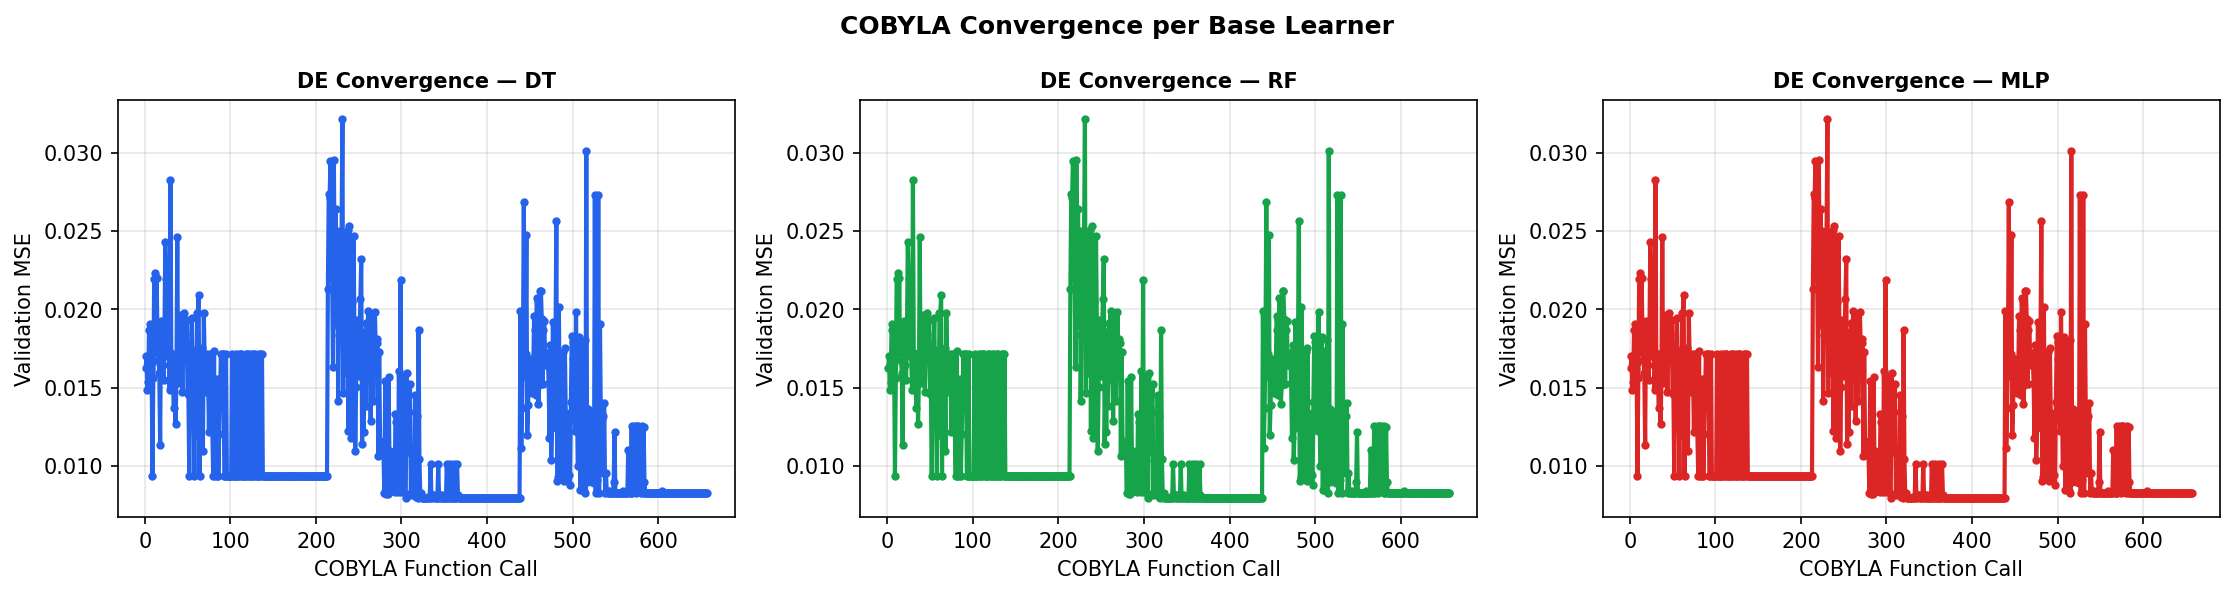

In [ ]:
# ── Cell 7 : DE Convergence Plots (one per base learner) ───────────────────
LEARNER_COLORS = {'dt': '#2563EB', 'rf': '#16A34A', 'mlp': '#DC2626'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)
for ax, (clf_name, _) in zip(axes, BASE_LEARNERS):
    hist_file = os.path.join(CACHE_DIR, f'de_history_{clf_name}.npy')
    if os.path.exists(hist_file):
        hist = np.load(hist_file)
        ax.plot(hist[:, 0], hist[:, 1],
                color=LEARNER_COLORS[clf_name], linewidth=2, marker='o', markersize=3)
        ax.set_title(f'DE Convergence — {clf_name.upper()}', fontsize=10, fontweight='bold')
        ax.set_xlabel('COBYLA Function Call', fontsize=10)
        ax.set_ylabel('Validation MSE', fontsize=10)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'{clf_name}: loaded from cache',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(f'{clf_name.upper()} — cache hit', fontsize=10)

plt.suptitle('COBYLA Convergence per Base Learner', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig1_cobyla_convergence.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 8 : Quantum Feature Computation (train + val + test per learner) ─────
#
# Each base learner has its own optimal weights → separate quantum features.

qfeatures = {}  # qfeatures[clf_name] = {'train': ..., 'val': ..., 'test': ...}

for clf_name, _ in BASE_LEARNERS:
    w = best_weights[clf_name]
    f_train = os.path.join(CACHE_DIR, f'X_train_q_{clf_name}_{HASH}.npy')
    f_val   = os.path.join(CACHE_DIR, f'X_val_q_{clf_name}_{HASH}.npy')
    f_test  = os.path.join(CACHE_DIR, f'X_test_q_{clf_name}_{HASH}.npy')

    if os.path.exists(f_train) and os.path.exists(f_val) and os.path.exists(f_test):
        print(f'  [{clf_name}] Loading quantum features from cache.')
        qfeatures[clf_name] = {
            'train': np.load(f_train),
            'val':   np.load(f_val),
            'test':  np.load(f_test)
        }
    else:
        print(f'  [{clf_name}] Computing quantum features...')
        Xq_tr = quantum_feature_map(X_train, w, circuit_default, verbose=True)
        Xq_vl = quantum_feature_map(X_val,   w, circuit_default, verbose=True)
        Xq_te = quantum_feature_map(X_test,  w, circuit_default, verbose=True)
        np.save(f_train, Xq_tr)
        np.save(f_val,   Xq_vl)
        np.save(f_test,  Xq_te)
        qfeatures[clf_name] = {'train': Xq_tr, 'val': Xq_vl, 'test': Xq_te}

print('\nQuantum features ready.')
for clf_name, _ in BASE_LEARNERS:
    print(f'  {clf_name}: train={qfeatures[clf_name]["train"].shape}  '
          f'val={qfeatures[clf_name]["val"].shape}  '
          f'test={qfeatures[clf_name]["test"].shape}')

  [dt] Computing quantum features...
  Feature map: 917/9174 samples
  Feature map: 1834/9174 samples
  Feature map: 2751/9174 samples
  Feature map: 3668/9174 samples
  Feature map: 4585/9174 samples
  Feature map: 5502/9174 samples
  Feature map: 6419/9174 samples
  Feature map: 7336/9174 samples
  Feature map: 8253/9174 samples
  Feature map: 9170/9174 samples
  Feature map: 196/1966 samples
  Feature map: 392/1966 samples
  Feature map: 588/1966 samples
  Feature map: 784/1966 samples
  Feature map: 980/1966 samples
  Feature map: 1176/1966 samples
  Feature map: 1372/1966 samples
  Feature map: 1568/1966 samples
  Feature map: 1764/1966 samples
  Feature map: 1960/1966 samples
  Feature map: 196/1966 samples
  Feature map: 392/1966 samples
  Feature map: 588/1966 samples
  Feature map: 784/1966 samples
  Feature map: 980/1966 samples
  Feature map: 1176/1966 samples
  Feature map: 1372/1966 samples
  Feature map: 1568/1966 samples
  Feature map: 1764/1966 samples
  Feature map: 19

In [ ]:
# ── Cell 9 : Stacking Layer — 5-Fold CV Meta-Features ──────────────────────
#
# FIX: stacking CV uses X_trainval (train + val) — X_test never touched here.
# Base learners are retrained inside each fold on quantum features.

X_trainval = np.vstack([X_train, X_val])
Y_trainval = np.concatenate([Y_train, Y_val])

# Trainval quantum features per learner (concatenate train+val)
qfeatures_tv = {
    clf_name: np.vstack([qfeatures[clf_name]['train'], qfeatures[clf_name]['val']])
    for clf_name, _ in BASE_LEARNERS
}

kf = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)

# OOF (out-of-fold) predictions: shape (n_trainval, n_base_learners)
oof_preds = {clf_name: np.zeros(len(Y_trainval)) for clf_name, _ in BASE_LEARNERS}

print(f'Generating {N_SPLITS_CV}-fold OOF meta-features for stacking...')
for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_trainval)):
    for clf_name, clf_template in BASE_LEARNERS:
        Xq_tr_fold = qfeatures_tv[clf_name][tr_idx]
        Xq_vl_fold = qfeatures_tv[clf_name][vl_idx]
        clf_fold   = clone(clf_template)
        clf_fold.fit(Xq_tr_fold, Y_trainval[tr_idx])
        oof_preds[clf_name][vl_idx] = clf_fold.predict(Xq_vl_fold)
    print(f'  Fold {fold+1}/{N_SPLITS_CV} done.')

# Stack OOF predictions into meta-features
X_meta_train = np.column_stack([oof_preds[n] for n, _ in BASE_LEARNERS])
print(f'\nMeta-train shape: {X_meta_train.shape}  '
      f'(columns: {[n for n, _ in BASE_LEARNERS]})')

Generating 5-fold OOF meta-features for stacking...
  Fold 1/5 done.
  Fold 2/5 done.
  Fold 3/5 done.
  Fold 4/5 done.
  Fold 5/5 done.

Meta-train shape: (11140, 3)  (columns: ['dt', 'rf', 'mlp'])


In [ ]:
# ── Tune base learners on quantum training features (RandomizedSearchCV) ─────
print("\nTuning base learners on quantum training features...")
tuned_base = {}
for clf_name, clf_template in BASE_LEARNERS:
    Xq_tr = qfeatures[clf_name]['train']
    if clf_name == 'dt':
        tuned_base['dt']  = tune_base_learner(DecisionTreeRegressor(random_state=SEED), DT_PARAMS, Xq_tr, Y_train, 'DT',  DT_CACHE,  n_iter=20)
    elif clf_name == 'rf':
        tuned_base['rf']  = tune_base_learner(RandomForestRegressor(random_state=SEED, n_jobs=-1), RF_PARAMS, Xq_tr, Y_train, 'RF',  RF_CACHE,  n_iter=20)
    elif clf_name == 'mlp':
        tuned_base['mlp'] = tune_base_learner(Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor())]), MLP_PARAMS, Xq_tr, Y_train, 'MLP', MLP_CACHE, n_iter=20)

# ── Cell 10 : Train Base Learners on Full X_trainval ───────────────────────
# After OOF, retrain each base learner on the full trainval set
# to generate test meta-features.

trained_base = {}
print('Training base learners on full X_trainval...')
for clf_name, clf_template in BASE_LEARNERS:
    clf = clone(tuned_base[clf_name])
    clf.fit(qfeatures_tv[clf_name], Y_trainval)
    trained_base[clf_name] = clf
    print(f'  [{clf_name}] trained on {len(Y_trainval)} samples.')

# Generate test meta-features using base learners and test quantum features
X_meta_test = np.column_stack([
    trained_base[clf_name].predict(qfeatures[clf_name]['test'])
    for clf_name, _ in BASE_LEARNERS
])
print(f'Meta-test shape: {X_meta_test.shape}')


Tuning base learners on quantum training features...
  [DT] Tuning with RandomizedSearchCV (20 iter, 5-fold)...
  [DT] Best params : {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 7}
  [DT] Best CV MSE : 0.013704
  [RF] Tuning with RandomizedSearchCV (20 iter, 5-fold)...
  [RF] Best params : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
  [RF] Best CV MSE : 0.009638
  [MLP] Tuning with RandomizedSearchCV (20 iter, 5-fold)...
  [MLP] Best params : {'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__alpha': 0.0001, 'mlp__activation': 'relu'}
  [MLP] Best CV MSE : 0.010435
Training base learners on full X_trainval...
  [dt] trained on 11140 samples.
  [rf] trained on 11140 samples.
  [mlp] trained on 11140 samples.
Meta-test shape: (1966, 3)


In [ ]:
# ── Cell 11 : Meta-Learner (GBM) Tuning ─────────────────────────────────
#
#  RandomizedSearchCV
#   (broader search, cv=5, n_iter=30) for the GBM meta-learner.

META_PARAM_DIST = {
    'n_estimators':  [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth':     [2, 3, 4, 5],
    'subsample':     [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

META_CACHE = os.path.join(CACHE_DIR, 'meta_learner_gbm.joblib')

if os.path.exists(META_CACHE):
    meta_gbm = load(META_CACHE)
    print('Meta-learner loaded from cache.')
else:
    print(f'Tuning GBM meta-learner '
          f'(RandomizedSearchCV, 30 iter, {N_SPLITS_CV}-fold CV)...')
    gbm = GradientBoostingRegressor(random_state=SEED)
    search = RandomizedSearchCV(
        gbm, META_PARAM_DIST,
        n_iter=30,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV,
        random_state=SEED,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_meta_train, Y_trainval)
    meta_gbm = search.best_estimator_
    dump(meta_gbm, META_CACHE)
    print(f'  Best params: {search.best_params_}')
    print(f'  Best CV MSE: {-search.best_score_:.6f}')

Tuning GBM meta-learner (RandomizedSearchCV, 30 iter, 5-fold CV)...
  Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 2, 'learning_rate': 0.05}
  Best CV MSE: 0.008801


In [ ]:
# ── RF Meta-Learner (RandomizedSearchCV, cv=5) ────────────────────────────
RF_META_CACHE  = os.path.join(CACHE_DIR, 'meta_rf.joblib')
RF_META_PARAMS = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}
if os.path.exists(RF_META_CACHE):
    meta_rf = load(RF_META_CACHE)
    print('RF meta-learner loaded from cache.')
else:
    print(f'Tuning RF meta-learner (RandomizedSearchCV, 20 iter, {N_SPLITS_CV}-fold)...')
    s = RandomizedSearchCV(
        RandomForestRegressor(random_state=SEED, n_jobs=-1),
        RF_META_PARAMS, n_iter=20,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV, random_state=SEED, n_jobs=-1, verbose=0
    )
    s.fit(X_meta_train, Y_trainval)
    meta_rf = s.best_estimator_
    dump(meta_rf, RF_META_CACHE)
    print(f'  Best params: {s.best_params_}')
    print(f'  Best CV MSE: {-s.best_score_:.6f}')



Tuning RF meta-learner (RandomizedSearchCV, 20 iter, 5-fold)...
  Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 7}
  Best CV MSE: 0.008867


In [ ]:
def eval_model(model, X_te, Y_te, label, optimizer="—"):
    """Uniform evaluation: MSE, RMSE, MAE, R2, Pearson r, Spearman rho, Time, Memory."""
    tracemalloc.start()
    t0      = time.time()
    Y_pred  = model.predict(X_te)
    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    pr, _ = pearsonr(Y_te, Y_pred)
    sr, _ = spearmanr(Y_te, Y_pred)
    return {
        'Model':        label,
        'MSE':          mean_squared_error(Y_te, Y_pred),
        'RMSE':         np.sqrt(mean_squared_error(Y_te, Y_pred)),
        'MAE':          mean_absolute_error(Y_te, Y_pred),
        'R2':           r2_score(Y_te, Y_pred),
        'Pearson r':    round(pr, 4),
        'Spearman rho': round(sr, 4),
        'Time (s)':     round(elapsed, 4),
        'Memory (MB)':  round(peak / 1024**2, 4),
        'Optimizer':    optimizer,
        '_pred':        Y_pred,
    }

print('Final evaluation on X_test (touched once):')
rows = []

# Base learners
for clf_name, _ in BASE_LEARNERS:
    r = eval_model(trained_base[clf_name], qfeatures[clf_name]['test'], Y_test,
                   label=f'Hybrid {clf_name.upper()} (base)', optimizer='COBYLA')
    rows.append(r)

# Meta-learners
res_gbm = eval_model(meta_gbm, X_meta_test, Y_test,
                     label='Stacking — GBM meta',
                     optimizer='RandomizedSearchCV (30 iter, 5-fold)')
res_rf  = eval_model(meta_rf,  X_meta_test, Y_test,
                     label='Stacking — RF meta',
                     optimizer='RandomizedSearchCV (20 iter, 5-fold)')
rows += [res_gbm, res_rf]

preds      = {r['Model']: r.pop('_pred') for r in rows}
results_df = pd.DataFrame(rows).set_index('Model')
display_cols = ['MSE', 'RMSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho', 'Time (s)', 'Memory (MB)', 'Optimizer']

print('\n── Test Set Results ──')
print(results_df[display_cols].round(4).to_string())


Final evaluation on X_test (touched once):

── Test Set Results ──
                        MSE    RMSE     MAE      R2  Pearson r  Spearman rho  Time (s)  Memory (MB)                             Optimizer
Model                                                                                                                                    
Hybrid DT (base)     0.0137  0.1170  0.0870  0.2845     0.5345        0.4694    0.0007       0.1219                                COBYLA
Hybrid RF (base)     0.0090  0.0946  0.0680  0.5315     0.7555        0.7313    0.4371       0.3791                                COBYLA
Hybrid MLP (base)    0.0107  0.1035  0.0766  0.4402     0.6636        0.6031    0.0310       3.0613                                COBYLA
Stacking — GBM meta  0.0086  0.0927  0.0663  0.5507     0.7480        0.7289    0.0122       0.0535  RandomizedSearchCV (30 iter, 5-fold)
Stacking — RF meta   0.0089  0.0943  0.0678  0.5347     0.7436        0.7259    0.2855       0.2764  Rand

/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


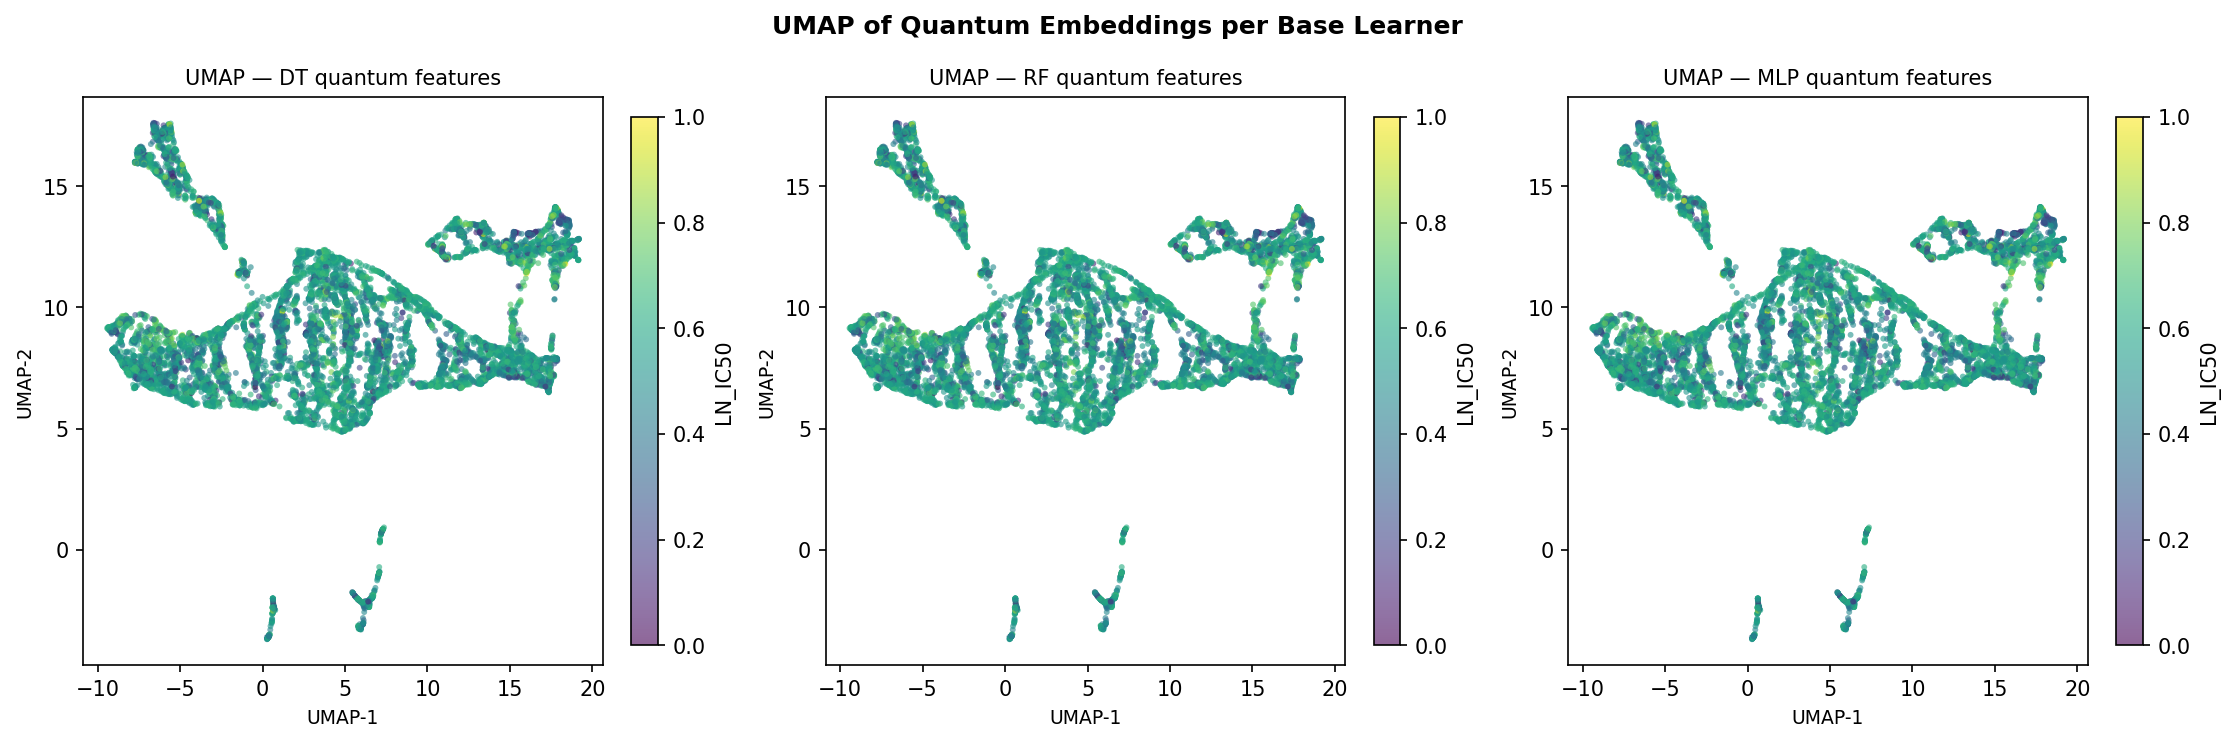

In [ ]:
# ──  UMAP of Quantum Embeddings (per base learner) ────────────────
if UMAP_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)
    for ax, (clf_name, _) in zip(axes, BASE_LEARNERS):
        Xq_tv = qfeatures_tv[clf_name]
        reducer = umap.UMAP(n_components=2, random_state=SEED,
                            n_neighbors=15, min_dist=0.1)
        X_2d = reducer.fit_transform(Xq_tv)
        sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                        c=Y_trainval, cmap='viridis',
                        s=8, alpha=0.6, edgecolors='none')
        plt.colorbar(sc, ax=ax, label='LN_IC50', fraction=0.046)
        ax.set_title(f'UMAP — {clf_name.upper()} quantum features', fontsize=10)
        ax.set_xlabel('UMAP-1', fontsize=9)
        ax.set_ylabel('UMAP-2', fontsize=9)

    plt.suptitle('UMAP of Quantum Embeddings per Base Learner',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'fig5_umap.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('UMAP not available. Install with: pip install umap-learn')